# 03 - Phân tích Khám phá & Mã hóa dữ liệu (EDA & Encoding)

### Phát biểu bài toán:
- **Mục tiêu:** Phân tích mức độ ảnh hưởng của các thông số kỹ thuật (Pin, Trọng lượng, tính năng Wireless...) và Thương hiệu đến giá của tai nghe.
- **Bài toán:** Khảo sát tính khả thi để xây dựng mô hình dự đoán `price_vnd` (biến số liên tục) -> Đây là bài toán **Hồi quy (Regression)**.

### Các bước thực hiện trong Notebook này:
1. **Thiết lập & Nạp dữ liệu:** Chuẩn bị môi trường và dữ liệu sạch.
2. **Feature Engineering:** Trích xuất các đặc trưng công nghệ mới.
3. **Trực quan hóa đa biến (EDA Nâng cao):** Khám phá mối quan hệ giữa các biến.
4. **Mã hóa dữ liệu (Data Encoding):** Chuyển đổi dữ liệu chữ sang số cho Machine Learning.
5. **Phân tích đa chiều (t-SNE):** Khảo sát tính phân cụm của dữ liệu.
6. **Kết luận:** Đánh giá tính khả thi của bài toán.


# 1. Thiết lập môi trường & Nạp dữ liệu

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os

# Cấu hình giao diện biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 8)

# Hàm rút gọn tiền tệ (Ví dụ: 5.000.000 -> 5 Tr)
def millions_formatter(x, pos):
    return f'{x * 1e-6:g} Tr'
formatter = ticker.FuncFormatter(millions_formatter)

# Đọc dữ liệu đã clean từ bước trước
file_path = '../clean_data/headphone_clean.csv'
df = pd.read_csv(file_path)
print(f"Đã nạp thành công dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")


Đã nạp thành công dữ liệu: 986 dòng, 13 cột.


---
## 2. Trích xuất đặc trưng (Feature Engineering)
Nhóm thực hiện tạo các đặc trưng kỹ thuật mới từ dữ liệu thô để tăng cường khả năng phân loại cho mô hình ở giai đoạn sau.

In [11]:
# Tạo các đặc trưng Boolean (0/1)
if 'connection' in df.columns:
    df['is_wireless'] = df['connection'].astype(str).str.lower().str.contains('wireless|bluetooth', na=False).astype(int)

if 'type' in df.columns:
    df['is_gaming'] = df['type'].astype(str).str.lower().str.contains('gaming', na=False).astype(int)

# Tỷ lệ giá trên Driver
if 'driver_size_mm' in df.columns:
    df['price_per_driver_mm'] = (df['price_vnd'] / 1e6) / df['driver_size_mm'].replace(0, np.nan)

display(df[['price_vnd', 'is_wireless', 'is_gaming']].head(3))

,price_vnd,is_wireless,is_gaming
0,11990000,0,0
1,14900000,0,0
2,7990000,0,0


---
# 3.1 Xu hướng giá theo trọng lượng và pin

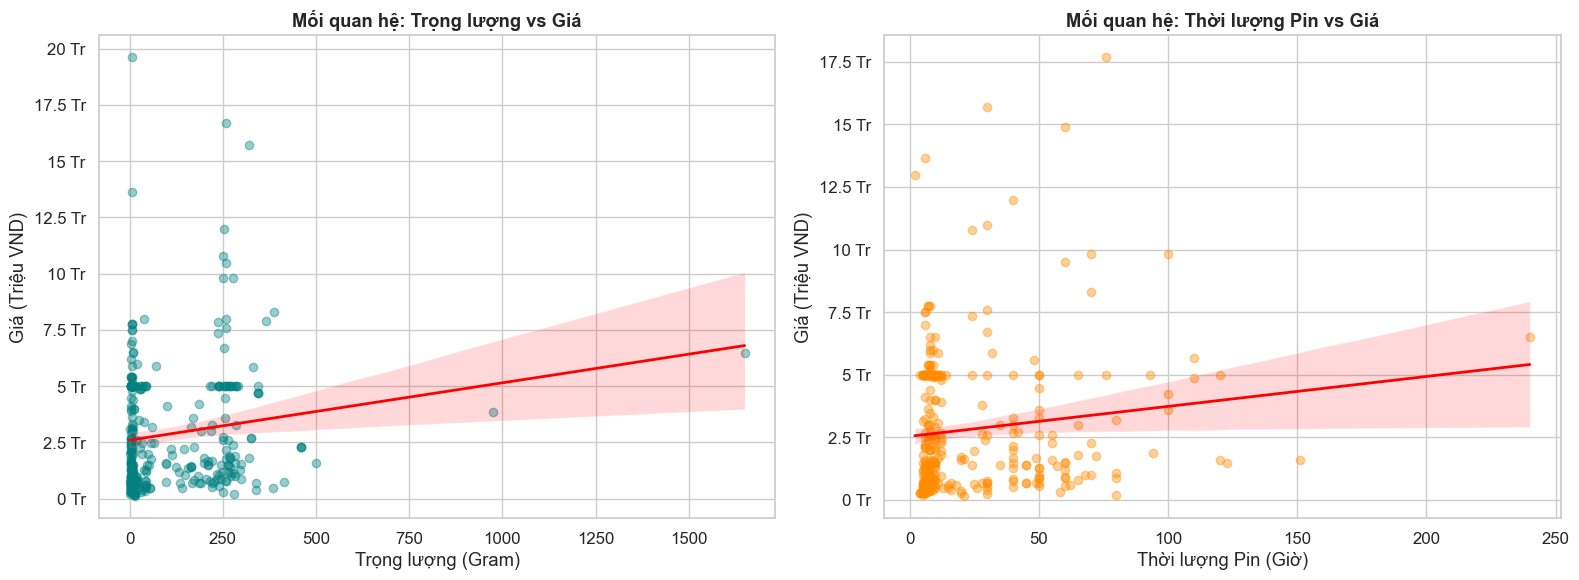

In [13]:

plt.figure(figsize=(16, 6))
ax1 = plt.subplot(1, 2, 1)
sns.regplot(data=df, x='weight_gram', y='price_vnd', scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red', 'lw':2})
ax1.yaxis.set_major_formatter(formatter)
plt.title('Mối quan hệ: Trọng lượng vs Giá', fontweight='bold')
plt.xlabel('Trọng lượng (Gram)')
plt.ylabel('Giá (Triệu VND)')

ax2 = plt.subplot(1, 2, 2)
sns.regplot(data=df, x='battery_life_hours', y='price_vnd', scatter_kws={'alpha':0.4, 'color':'darkorange'}, line_kws={'color':'red', 'lw':2})
ax2.yaxis.set_major_formatter(formatter)
plt.title('Mối quan hệ: Thời lượng Pin vs Giá', fontweight='bold')
plt.xlabel('Thời lượng Pin (Giờ)')
plt.ylabel('Giá (Triệu VND)')
plt.tight_layout()
plt.show()


**Nhận xét xu hướng theo trọng lượng và pin:**
- Trọng lượng (weight_gram): Đường xu hướng dốc lên rõ rệt thể hiện sự đồng biến với Giá. Các dòng tai nghe cao cấp (thường là Over-ear) sử dụng nhiều vật liệu kim loại, củ loa lớn, khiến trọng lượng nặng hơn đáng kể so với tai nghe vỏ nhựa giá rẻ.
- Thời lượng Pin (battery_life_hours): Rất nhiều mẫu tai nghe bình dân hiện nay vẫn có thời lượng pin cực khủng (40-50 giờ) để hút khách, trong khi nhiều dòng đắt tiền lại tập trung vào chip DAC/AMP hao pin hơn. Do đó, Pin không phải là yếu tố tiên quyết để phân loại giá.

---
# 3.2 Xếp hạng Thương hiệu theo Phân khúc giá (Boxplot sorted)

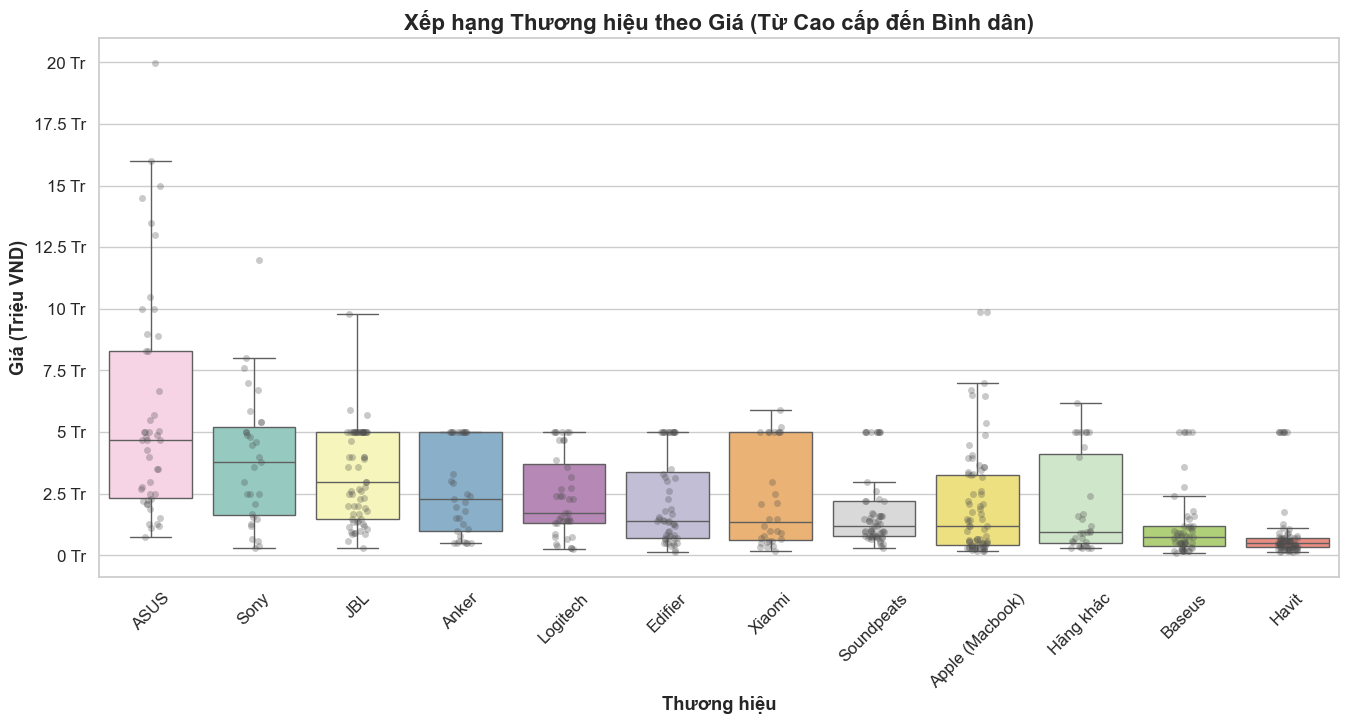

In [18]:
top_12_brands = df['brand'].value_counts().nlargest(12).index
df_plot = df[df['brand'].isin(top_12_brands)]
order = df_plot.groupby('brand')['price_vnd'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 7))
ax = sns.boxplot(data=df_plot, x='brand', y='price_vnd', order=order, palette='Set3', showfliers=False, hue='brand', legend=False)
sns.stripplot(data=df_plot, x='brand', y='price_vnd', order=order, color=".3", alpha=0.3, jitter=True)
ax.yaxis.set_major_formatter(formatter)
plt.title('Xếp hạng Thương hiệu theo Giá (Từ Cao cấp đến Bình dân)', fontweight='bold', fontsize=16)
plt.xlabel('Thương hiệu', fontweight='bold')
plt.ylabel('Giá (Triệu VND)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

**Nhận xét theo thương hiệu:**
- Sức mạnh Thương hiệu: Biểu đồ Boxplot cho thấy giá trị thương hiệu đóng vai trò định đoạt phân khúc giá. Các ông lớn (Apple, Sony) có biên độ giá rất rộng và nhiều điểm dị biệt vươn lên mốc hàng chục triệu, trong khi các hãng phổ thông (JBL, Soundpeats) co cụm ở vùng giá thấp. Thương hiệu chắc chắn là một biến phân loại cực mạnh.

# 3.3 Ma trận tương quan tổng thể

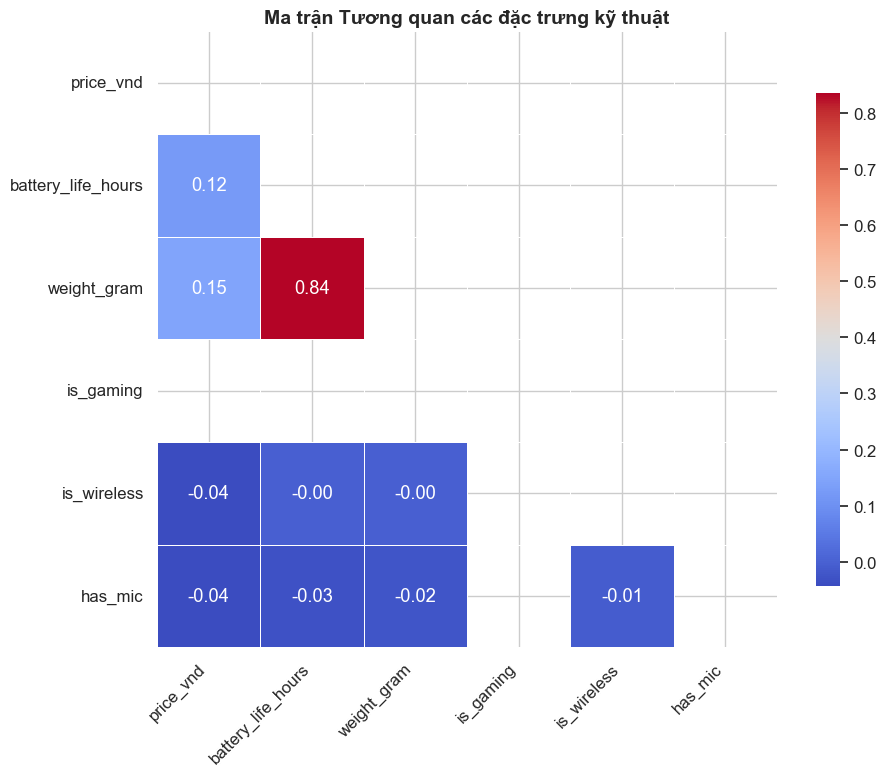

In [15]:

num_features = ['price_vnd', 'battery_life_hours', 'weight_gram', 'is_gaming', 'is_wireless', 'has_mic', 'price_per_driver_mm']
num_features = [c for c in num_features if c in df.columns]

corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Che nửa trên để tránh rối mắt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Ma trận Tương quan các đặc trưng kỹ thuật', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

**Nhận xét ma trận tương quan:**
Nhìn vào cột biến mục tiêu `price_vnd`, ta thấy `weight_gram` có hệ số tương quan dương cao nhất, tái khẳng định đây là một biến dự báo tốt. `is_wireless` có tương quan thuận ở mức khá, cho thấy kết nối không dây là một điểm cộng gia tăng giá trị định giá. Ngược lại, `is_gaming` và pin có hệ số rất thấp, ít tạo ra sự phân hóa giá trị tổng thể.

---
## 4. Mã hóa dữ liệu (Data Encoding)
Để các thuật toán Machine Learning có thể học được "Hệ số uy tín" của Thương hiệu, nhóm tiến hành Gom nhóm (tránh bùng nổ số chiều) và Mã hóa One-Hot các biến danh mục.

In [16]:
df_encoded = df.copy()

# 4.1 Gom nhóm Brand (Giữ Top 15, còn lại là Other)
if 'brand' in df_encoded.columns:
    top_15_brands = df_encoded['brand'].value_counts().nlargest(15).index
    df_encoded['brand_grouped'] = df_encoded['brand'].apply(lambda x: x if x in top_15_brands else 'Other')

# 4.2 Mã hóa One-Hot (Sử dụng drop_first=True tránh đa cộng tuyến)
cols_to_encode = ['brand_grouped', 'type']
cols_to_encode = [c for c in cols_to_encode if c in df_encoded.columns]

if cols_to_encode:
    df_encoded = pd.get_dummies(df_encoded, columns=cols_to_encode, drop_first=True)
    
    # Chuyển đổi Boolean sang 0/1 cho mô hình dễ đọc
    for col in df_encoded.columns:
        if df_encoded[col].dtype == bool:
            df_encoded[col] = df_encoded[col].astype(int)

print(f"Kích thước sau khi mã hóa: {df_encoded.shape}")

# 4.3 Xuất file dữ liệu sẵn sàng cho Machine Learning
out_dir = '../clean_data/'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'headphone_encoded_for_ml.csv')
df_encoded.to_csv(out_path, index=False)
print(f"Đã xuất file thành công tại: {out_path}")

Kích thước sau khi mã hóa: (986, 28)
Đã xuất file thành công tại: ../clean_data/headphone_encoded_for_ml.csv


---
## 5. Phân tích đa chiều với t-SNE
Sau khi đã mã hóa và có đầy đủ các đặc trưng, nhóm sử dụng thuật toán t-SNE để nén toàn bộ thông số kỹ thuật đa chiều xuống không gian 2D, nhằm kiểm tra xem dữ liệu có hình thành các cụm (cluster) tự nhiên theo phân khúc giá hay không.

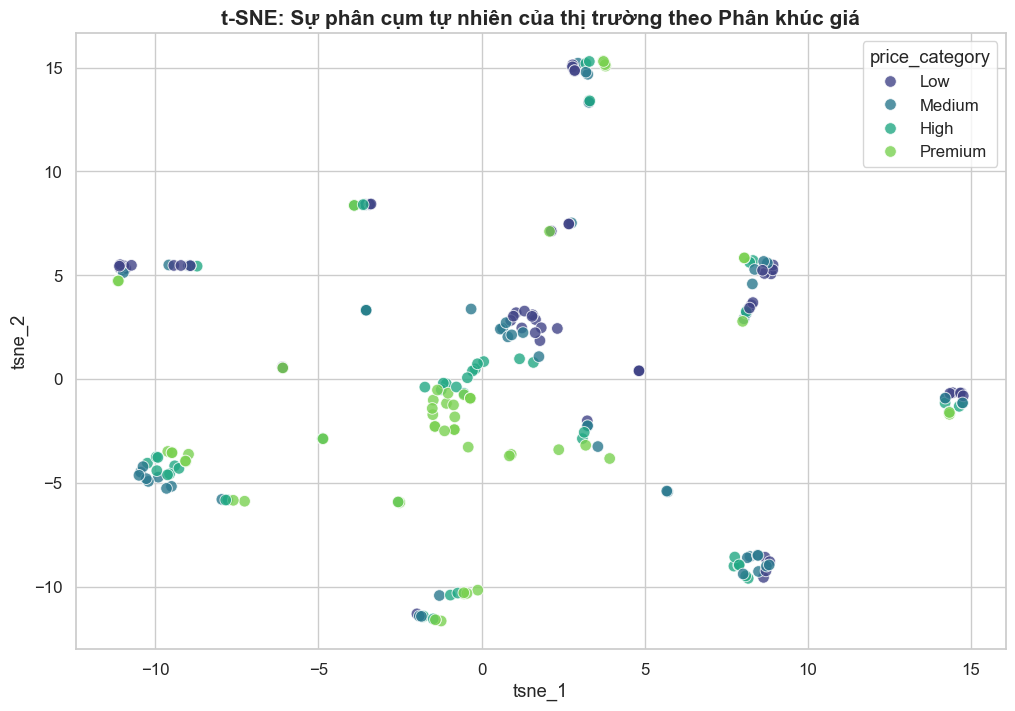

In [17]:
# Lọc bỏ cột không biến thiên để tránh lỗi thuật toán
df_tsne_data = df_encoded.select_dtypes(include=[np.number]).dropna()
df_tsne_data = df_tsne_data.loc[:, df_tsne_data.std() > 0]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_tsne_data)

# Chạy t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
results = tsne.fit_transform(scaled_data)

df_tsne_data['tsne_1'] = results[:, 0]
df_tsne_data['tsne_2'] = results[:, 1]

# Chia 4 phân khúc giá để tô màu
df_tsne_data['price_category'] = pd.qcut(df_tsne_data['price_vnd'], q=4, labels=['Low', 'Medium', 'High', 'Premium'])

# Trực quan hóa t-SNE
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_tsne_data, x='tsne_1', y='tsne_2', hue='price_category', palette='viridis', s=70, alpha=0.8)
plt.title('t-SNE: Sự phân cụm tự nhiên của thị trường theo Phân khúc giá', fontweight='bold', fontsize=15)
plt.show()

**Nhận xét biểu đồ t-SNE:**
Quan sát sự phân bổ, ta thấy các sản phẩm thuộc cùng một phân khúc giá không phân bố ngẫu nhiên mà hội tụ thành những "cụm" (clusters) đặc thù. Vùng giá rẻ (Low) nằm tách biệt khá rõ so với vùng cao cấp (Premium). Sự phân cụm rõ rệt này là tín hiệu cực kỳ khả quan, chứng tỏ tập dữ liệu có tính quy luật cao.

---
## 6. Kết luận & Đánh giá tính khả thi

Dựa trên quá trình phân tích (EDA) và khảo sát đa chiều, nhóm rút ra các kết luận sau:

1. **Tính khả thi của bài toán:** Bài toán dự báo giá tai nghe (Hồi quy) là **HOÀN TOÀN KHẢ THI**. Ma trận tương quan và biểu đồ t-SNE đều chứng minh dữ liệu có khả năng phân tách thị trường. Các thuật toán Học máy ở giai đoạn sau hoàn toàn có thể dựa vào ranh giới này để học quy luật định giá.
2. **Tập đặc trưng (Features) hữu ích nhất:**
   - **Đặc trưng Số học:** `weight_gram` (tín hiệu mạnh), `price_per_driver_mm`, `battery_life_hours`.
   - **Đặc trưng Công nghệ:** `is_wireless`, `is_gaming`.
   - **Đặc trưng Danh mục:** `brand_grouped` (đã mã hóa) và `type`.

---

## 7. Tài liệu tham khảo

- Gợi ý nguồn dữ liệu: `gearvn.com`, `cellphones.com.vn`, `phongvu.vn`, `pcpartpicker.com`, Tiki/Shopee (category tai nghe/headphone).
- Kỹ thuật Feature Engineering: https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- Giới thiệu t-SNE: https://www.datacamp.com/tutorial/introduction-t-sne
- Cách trình bày notebook tham khảo: folder mẫu 10-Data-Capstone-Projects (GV cung cấp).